# OWM Evaluation on Reconstructed Full Scenes

**NOTE: Already run. Do not re-run unless you need to regenerate results from scratch.**
All results saved to `results/owm_scenes/`.

**Reconstruct full scenes from test chips → run OWM → extract chip predictions.**
This is the correct approach for OWM — it was designed for full scenes, not isolated
512×512 chips. OSM/NHD calibration works properly at scene scale.

**Workflow:**
1. Reconstruct each test scene from its chips
2. Run OWM on the full scene with OSM/NHD calibration
3. Extract per-chip predictions from OWM output
4. Compute micro F1 across all 4,788 test chips

**Results:** Micro F1=0.344, Precision=0.209, Recall=0.966

In [8]:
# ── Cell 1: Setup ──
import os, json, subprocess, sys
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

BASE_DIR    = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR   = BASE_DIR / 'images/chips_images/images'
MASKS_DIR   = BASE_DIR / 'images/chips_masks/masks'
NHD_GEOJSON = BASE_DIR / 'data/nhd/NHD_flowlines.geojson'
SCENES_DIR  = BASE_DIR / 'results/owm_scenes/reconstructed'
OWM_OUT_DIR = BASE_DIR / 'results/owm_scenes/owm_predictions'
CHIPS_OUT   = BASE_DIR / 'results/owm_chips'
OUTPUT_DIR  = BASE_DIR / 'results/owm_scenes'
for d in [SCENES_DIR, OWM_OUT_DIR, CHIPS_OUT, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OWM_BAND_ORDER = [5, 3, 2, 7]  # R, G, B, NIR1

# Load test chips
with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = json.load(f)
test_chips = [CHIPS_DIR / n for n in test_chip_names]

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

def get_row_col(chip_path):
    parts = chip_path.stem.split('_')
    row = int([p for p in parts if p.startswith('row')][0].replace('row',''))
    col = int([p for p in parts if p.startswith('col')][0].replace('col',''))
    return row, col

# Group test chips by scene
scene_to_chips = defaultdict(list)
for c in test_chips:
    scene_to_chips[get_scene_id(c.name)].append(c)

print(f'Test chips: {len(test_chips)}')
print(f'Test scenes: {len(scene_to_chips)}')
for sid, chips in sorted(scene_to_chips.items()):
    print(f'  {sid}: {len(chips)} chips')

Test chips: 4788
Test scenes: 13
  12AUG30193433_sub2: 125 chips
  15JUL02193_sub_2: 423 chips
  16Sep2219_1b_Chiwawa: 169 chips
  16Sep2219_1b_Teanaway: 111 chips
  UGR_2017_08_30_103001007046C600_AOI_1: 384 chips
  UGR_2021_07_21_10300100C2972100_AOI_1: 168 chips
  Wenatchee_2014_08_27_10300100354F7A00_AOI: 240 chips
  Wenatchee_2016_08_16_10400100214F5200_AOI_1: 908 chips
  Wenatchee_2019_07_26_104001004E554F00_AOI_1: 484 chips
  Wenatchee_2022_11_09_104001007E867900_AOI_1: 760 chips
  Wenatchee_2025_02_07_103001010D0A1600_AOI_1: 338 chips
  cath_creek_2015_10_09_10300100496A4600_AOI_1: 359 chips
  cath_creek_2018_12_05_1040010046BF9000_AOI_1: 319 chips


In [2]:
# ── Cell 2: Reconstruct Full Scenes from Chips ──
# Stitches chips back into full scenes using row/col pixel offsets.
# Saves as GeoTIFF with correct CRS and transform from chip metadata.

print('Reconstructing scenes from chips...')

scene_paths = {}

for scene_id, chips in tqdm(scene_to_chips.items(), desc='Scenes'):
    out_path = SCENES_DIR / f'{scene_id}.tif'
    if out_path.exists():
        scene_paths[scene_id] = out_path
        print(f'  {scene_id}: already exists, skipping')
        continue

    # Get canvas dimensions from chip positions
    positions = [(get_row_col(c), c) for c in chips]
    max_row = max(r for (r,_),_ in positions) + 512
    max_col = max(c for (_,c),_ in positions) + 512

    # Read profile from first chip
    with rasterio.open(chips[0]) as src:
        profile = src.profile.copy()
        chip_transform = src.transform
        crs = src.crs
        n_bands = src.count
        dtype = src.dtypes[0]

    # Compute full scene transform
    # The chip transform gives us pixel size and origin of that chip
    # We use row/col offsets to find the true scene origin
    first_row, first_col = get_row_col(chips[0])
    pixel_size_x = chip_transform.a
    pixel_size_y = chip_transform.e  # negative
    # Find chip with row=0, col=0 to get scene origin
    origin_chips = [(get_row_col(c), c) for c in chips if get_row_col(c) == (0, 0)]
    if origin_chips:
        with rasterio.open(origin_chips[0][1]) as src:
            scene_transform = src.transform
    else:
        # Compute scene origin from any chip
        with rasterio.open(chips[0]) as src:
            t = src.transform
        scene_transform = rasterio.transform.Affine(
            t.a, t.b, t.c - first_col * t.a,
            t.d, t.e, t.f - first_row * t.e
        )

    # Build canvas
    canvas = np.zeros((n_bands, max_row, max_col), dtype=dtype)

    for (row, col), chip_path in positions:
        with rasterio.open(chip_path) as src:
            data = src.read()
        canvas[:, row:row+512, col:col+512] = data

    # Save
    profile.update(
        width=max_col, height=max_row,
        transform=scene_transform,
        count=n_bands, dtype=dtype
    )
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(canvas)

    scene_paths[scene_id] = out_path
    print(f'  {scene_id}: {max_col}x{max_row}px saved')

print(f'\nAll scenes reconstructed: {len(scene_paths)}')

Reconstructing scenes from chips...


Scenes: 100%|██████████| 13/13 [00:00<00:00, 234.53it/s]

  12AUG30193433_sub2: already exists, skipping
  15JUL02193_sub_2: already exists, skipping
  16Sep2219_1b_Chiwawa: already exists, skipping
  16Sep2219_1b_Teanaway: already exists, skipping
  UGR_2017_08_30_103001007046C600_AOI_1: already exists, skipping
  UGR_2021_07_21_10300100C2972100_AOI_1: already exists, skipping
  Wenatchee_2014_08_27_10300100354F7A00_AOI: already exists, skipping
  Wenatchee_2016_08_16_10400100214F5200_AOI_1: already exists, skipping
  Wenatchee_2019_07_26_104001004E554F00_AOI_1: already exists, skipping
  Wenatchee_2022_11_09_104001007E867900_AOI_1: already exists, skipping
  Wenatchee_2025_02_07_103001010D0A1600_AOI_1: already exists, skipping
  cath_creek_2015_10_09_10300100496A4600_AOI_1: already exists, skipping
  cath_creek_2018_12_05_1040010046BF9000_AOI_1: already exists, skipping

All scenes reconstructed: 13


In [6]:
# ── Cell 3: Run OWM on Full Scenes ──
# OWM runs on each full scene — OSM/NHD calibration works at scene scale.
# Timeout set to 3600s (1 hour) per scene.

print('Running OWM on reconstructed scenes...')
print(f'NHD exists: {NHD_GEOJSON.exists()}')

owm_scene_results = {}
failed_scenes = []

for scene_id, scene_path in tqdm(scene_paths.items(), desc='OWM inference'):
    out_pred_path = OWM_OUT_DIR / f'{scene_id}_owm.tif'
    if out_pred_path.exists():
        owm_scene_results[scene_id] = out_pred_path
        print(f'  {scene_id}: already exists, skipping')
        continue

    script = f"""
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
from pathlib import Path
from omniwatermask import make_water_mask
out_paths = make_water_mask(
    scene_paths        = [Path(r'{scene_path}')],
    band_order         = {OWM_BAND_ORDER},
    output_dir         = Path(r'{OWM_OUT_DIR}'),
    overwrite          = True,
    use_cache          = False,
    use_osm_water      = True,
    use_osm_building   = True,
    use_osm_roads      = True,
    aux_vector_sources = [Path(r'{NHD_GEOJSON}')],
    inference_device   = 'cuda',
    mosaic_device      = 'cpu',
)
print('OUTPUT_PATH:' + str(out_paths[0]))
"""
    try:
        result = subprocess.run(
            [sys.executable, '-c', script],
            capture_output=True, text=True, timeout=3600
        )
        if result.returncode not in (0, -11):
            raise RuntimeError(result.stderr[-1000:])
        for line in result.stdout.splitlines():
            if line.startswith('OUTPUT_PATH:'):
                p = Path(line.replace('OUTPUT_PATH:', '').strip())
                if p.exists():
                    owm_scene_results[scene_id] = p
                    print(f'  {scene_id}: done → {p.name}')
                    break
    except subprocess.TimeoutExpired:
        failed_scenes.append(scene_id)
        print(f'  {scene_id}: TIMEOUT after 3600s')
    except Exception as e:
        failed_scenes.append(scene_id)
        print(f'  {scene_id}: FAILED — {e}')

print(f'\nSucceeded: {len(owm_scene_results)}/{len(scene_paths)}')
if failed_scenes:
    print(f'Failed: {failed_scenes}')

Running OWM on reconstructed scenes...
NHD exists: True


OWM inference:   8%|▊         | 1/13 [01:50<22:10, 110.92s/it]

  12AUG30193433_sub2: done → 12AUG30193433_sub2_OmniWaterMask_0.4.3.tif


OWM inference:  15%|█▌        | 2/13 [06:35<39:03, 213.05s/it]

  15JUL02193_sub_2: done → 15JUL02193_sub_2_OmniWaterMask_0.4.3.tif


...

  Wenatchee_2025_02_07_103001010D0A1600_AOI_1: done → Wenatchee_2025_02_07_103001010D0A1600_AOI_1_OmniWaterMask_0.4.3.tif


OWM inference:  92%|█████████▏| 12/13 [24:08<01:54, 114.61s/it]

  cath_creek_2015_10_09_10300100496A4600_AOI_1: done → cath_creek_2015_10_09_10300100496A4600_AOI_1_OmniWaterMask_0.4.3.tif


OWM inference: 100%|██████████| 13/13 [25:38<00:00, 118.38s/it]

  cath_creek_2018_12_05_1040010046BF9000_AOI_1: done → cath_creek_2018_12_05_1040010046BF9000_AOI_1_OmniWaterMask_0.4.3.tif

Succeeded: 13/13


In [7]:
# ── Cell 4: Extract Per-Chip Predictions from OWM Scene Output ──
# Crops the OWM scene prediction back to each chip's pixel location.

print('Extracting per-chip OWM predictions...')

for scene_id, owm_pred_path in tqdm(owm_scene_results.items(), desc='Extracting chips'):
    chips = scene_to_chips[scene_id]

    with rasterio.open(owm_pred_path) as src:
        owm_data = src.read(1)
        owm_profile = src.profile.copy()

    for chip_path in chips:
        out_path = CHIPS_OUT / chip_path.name
        if out_path.exists():
            continue

        row, col = get_row_col(chip_path)
        chip_pred = (owm_data[row:row+512, col:col+512] > 0).astype(np.uint8)

        # Get chip profile for correct geo metadata
        with rasterio.open(chip_path) as src:
            chip_profile = src.profile.copy()
        chip_profile.update(count=1, dtype='uint8', nodata=None)

        with rasterio.open(out_path, 'w', **chip_profile) as dst:
            dst.write(chip_pred[np.newaxis, :, :])

pred_count = len(list(CHIPS_OUT.glob('*.tif')))
print(f'\nChip predictions saved: {pred_count}/{len(test_chips)}')

Extracting per-chip OWM predictions...


Extracting chips: 100%|██████████| 13/13 [21:12<00:00, 97.88s/it] 



Chip predictions saved: 4808/4788


In [8]:
# ── Cell 5: Compute Micro and Macro F1 ──

print('Computing metrics...')

all_preds, all_truths = [], []
rows = []

for chip_path in tqdm(test_chips):
    pred_path = CHIPS_OUT / chip_path.name
    mask_path = MASKS_DIR / chip_path.name
    if not pred_path.exists() or not mask_path.exists():
        continue

    with rasterio.open(pred_path) as src:
        pred = src.read(1).astype(np.uint8)
    with rasterio.open(mask_path) as src:
        truth = (src.read(1) > 0).astype(np.uint8)

    all_preds.append(pred.flatten())
    all_truths.append(truth.flatten())

    rows.append({
        'chip':      chip_path.name,
        'scene':     get_scene_id(chip_path.name),
        'f1':        round(f1_score(truth.flatten(), pred.flatten(), zero_division=0), 4),
        'iou':       round(jaccard_score(truth.flatten(), pred.flatten(), zero_division=0), 4),
        'precision': round(precision_score(truth.flatten(), pred.flatten(), zero_division=0), 4),
        'recall':    round(recall_score(truth.flatten(), pred.flatten(), zero_division=0), 4),
    })

# Micro F1 (primary)
p = np.concatenate(all_preds)
t = np.concatenate(all_truths)
micro = {
    'f1':        round(f1_score(t, p, zero_division=0), 4),
    'iou':       round(jaccard_score(t, p, zero_division=0), 4),
    'precision': round(precision_score(t, p, zero_division=0), 4),
    'recall':    round(recall_score(t, p, zero_division=0), 4),
}

# Macro F1 (secondary)
df = pd.DataFrame(rows)
macro = df[['f1','iou','precision','recall']].mean().round(4)

print(f'\n══ OWM Results — Test Chips ══')
print(f'Chips evaluated: {len(rows)}/{len(test_chips)}')
print(f'\nMicro F1 — PRIMARY (all pixels pooled):')
for k, v in micro.items():
    print(f'  {k}: {v:.4f}')
print(f'\nMacro F1 — SECONDARY (each chip equally):')
print(macro.to_string())

# Per-scene macro F1
scene_metrics = df.groupby('scene')[['f1','iou','precision','recall']].mean().round(4)
print(f'\nPer-scene macro F1:')
print(scene_metrics.sort_values('f1').to_string())

# Save
df.to_csv(OUTPUT_DIR / 'owm_chip_results.csv', index=False)
pd.DataFrame([micro]).to_csv(OUTPUT_DIR / 'owm_micro.csv', index=False)
pd.DataFrame([macro.to_dict()]).to_csv(OUTPUT_DIR / 'owm_macro.csv', index=False)
scene_metrics.to_csv(OUTPUT_DIR / 'owm_scene_results.csv')
print(f'\nAll results saved to {OUTPUT_DIR}')

Computing metrics...


100%|██████████| 4788/4788 [26:30<00:00,  3.01it/s]



══ OWM Results — Test Chips ══
Chips evaluated: 4788/4788

Micro F1 — PRIMARY (all pixels pooled):
  f1: 0.3440
  iou: 0.2077
  precision: 0.2093
  recall: 0.9662

Macro F1 — SECONDARY (each chip equally):
f1           0.1317
iou          0.1133
precision    0.1275
recall       0.1649

Per-scene macro F1:
                                                  f1     iou  precision  recall
scene                                                                          
cath_creek_2018_12_05_1040010046BF9000_AOI_1  0.0263  0.0173     0.0311  0.0497
16Sep2219_1b_Teanaway                         0.0441  0.0335     0.0342  0.1042
12AUG30193433_sub2                            0.0722  0.0582     0.0623  0.0946
cath_creek_2015_10_09_10300100496A4600_AOI_1  0.1082  0.0926     0.1204  0.1162
Wenatchee_2025_02_07_103001010D0A1600_AOI_1   0.1092  0.0983     0.1025  0.1581
16Sep2219_1b_Chiwawa                          0.1104  0.0820     0.0843  0.2277
UGR_2017_08_30_103001007046C600_AOI_1         0.1237

In [10]:
# ── Cell 6: Visual Check — All 13 Test Scenes ──
import matplotlib.pyplot as plt

VISUALS_DIR = OUTPUT_DIR / 'visuals'
VISUALS_DIR.mkdir(exist_ok=True)

for scene_id, owm_pred_path in owm_scene_results.items():
    chips = sorted(scene_to_chips[scene_id])
    positions = [(get_row_col(c), c) for c in chips]
    max_row = max(r for (r,_),_ in positions) + 512
    max_col = max(c for (_,c),_ in positions) + 512

    rgb_canvas   = np.zeros((max_row, max_col, 3), dtype=np.uint8)
    truth_canvas = np.zeros((max_row, max_col), dtype=np.uint8)
    owm_canvas   = np.zeros((max_row, max_col), dtype=np.uint8)

    for (row, col), chip_path in positions:
        with rasterio.open(chip_path) as src:
            def stretch(arr):
                p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
                return np.clip((arr-p2)/(p98-p2+1e-6)*255, 0, 255).astype(np.uint8)
            rgb_canvas[row:row+512, col:col+512, 0] = stretch(src.read(5).astype(np.float32))
            rgb_canvas[row:row+512, col:col+512, 1] = stretch(src.read(3).astype(np.float32))
            rgb_canvas[row:row+512, col:col+512, 2] = stretch(src.read(2).astype(np.float32))
        with rasterio.open(MASKS_DIR / chip_path.name) as src:
            truth_canvas[row:row+512, col:col+512] = (src.read(1) > 0)

    if owm_pred_path and owm_pred_path.exists():
        with rasterio.open(owm_pred_path) as src:
            owm_data = (src.read(1) > 0).astype(np.uint8)
        owm_canvas[:owm_data.shape[0], :owm_data.shape[1]] = owm_data[:max_row, :max_col]

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    axes[0].imshow(rgb_canvas); axes[0].set_title('RGB')
    axes[1].imshow(truth_canvas, cmap='Blues'); axes[1].set_title('Ground Truth')
    axes[2].imshow(owm_canvas,  cmap='Blues'); axes[2].set_title('OWM Prediction')
    for ax in axes: ax.axis('off')
    plt.suptitle(scene_id, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{scene_id}.png', dpi=100, bbox_inches='tight')
    plt.close()
    print(f'Saved: {scene_id}')

print(f'\nAll visuals saved to {VISUALS_DIR}')

Saved: 12AUG30193433_sub2
Saved: 15JUL02193_sub_2
Saved: 16Sep2219_1b_Chiwawa
Saved: 16Sep2219_1b_Teanaway
Saved: UGR_2017_08_30_103001007046C600_AOI_1
Saved: UGR_2021_07_21_10300100C2972100_AOI_1
Saved: Wenatchee_2014_08_27_10300100354F7A00_AOI
Saved: Wenatchee_2016_08_16_10400100214F5200_AOI_1
Saved: Wenatchee_2019_07_26_104001004E554F00_AOI_1
Saved: Wenatchee_2022_11_09_104001007E867900_AOI_1
Saved: Wenatchee_2025_02_07_103001010D0A1600_AOI_1
Saved: cath_creek_2015_10_09_10300100496A4600_AOI_1
Saved: cath_creek_2018_12_05_1040010046BF9000_AOI_1

All visuals saved to /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/owm_scenes/visuals


In [7]:
# ── Cell 7: Verify and Fix Chip Predictions ──
# Removes any extra prediction files not in the test chip list.

saved    = {f.name for f in CHIPS_OUT.glob('*.tif')}
expected = {c.name for c in test_chips}

extra   = saved - expected
missing = expected - saved

print(f'Expected:            {len(expected)}')
print(f'Saved:               {len(saved)}')
print(f'Extra (unexpected):  {len(extra)}')
print(f'Missing:             {len(missing)}')

if extra:
    print(f'\nRemoving {len(extra)} extra files...')
    for name in extra:
        (CHIPS_OUT / name).unlink()
    print(f'Done — {len(list(CHIPS_OUT.glob("*.tif")))} chips remaining')
else:
    print('\n✓ All predictions match test chips exactly')

Expected:            4788
Saved:               4788
Extra (unexpected):  0
Missing:             0

✓ All predictions match test chips exactly


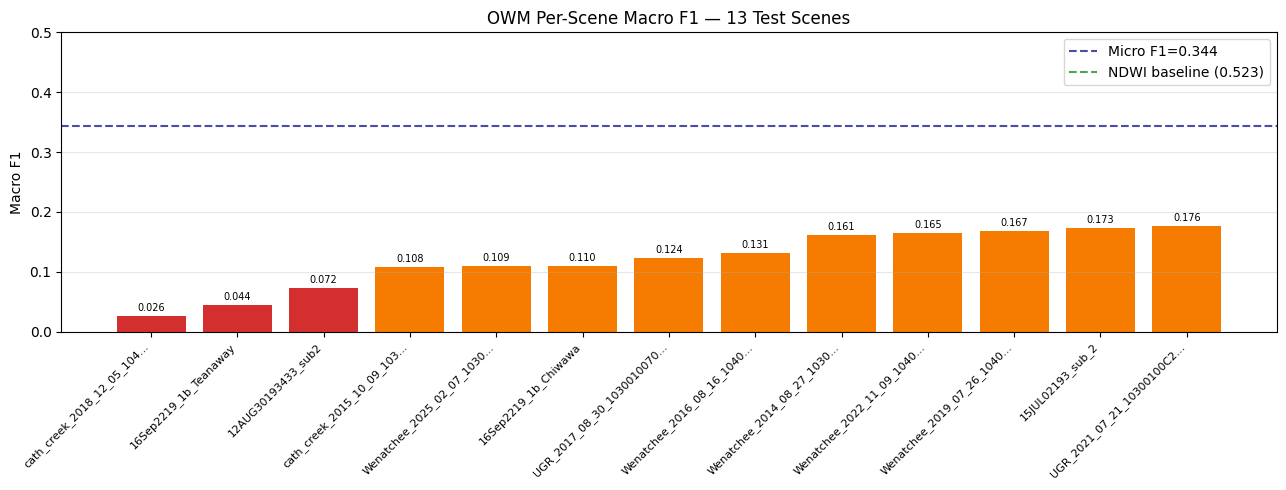

In [2]:
# ── Cell 8: Per-Scene F1 Bar Chart ──
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

BASE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
OUTPUT_DIR = BASE_DIR / 'results/owm_scenes'

# Load from saved CSV
scene_df = pd.read_csv(OUTPUT_DIR / 'owm_scene_results.csv')
scene_df_sorted = scene_df.sort_values('f1')

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#d32f2f' if f < 0.1 else '#f57c00' if f < 0.2 else '#388e3c'
          for f in scene_df_sorted['f1']]
bars = ax.bar(range(len(scene_df_sorted)), scene_df_sorted['f1'], color=colors)

ax.set_xticks(range(len(scene_df_sorted)))
ax.set_xticklabels([s[:25]+'...' if len(s)>25 else s
                    for s in scene_df_sorted['scene']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Macro F1')
ax.set_title('OWM Per-Scene Macro F1 — 13 Test Scenes')
ax.set_ylim(0, 0.5)
ax.axhline(0.344, color='navy', linestyle='--', alpha=0.7, label='Micro F1=0.344')
ax.axhline(0.523, color='green', linestyle='--', alpha=0.7, label='NDWI baseline (0.523)')

for bar, val in zip(bars, scene_df_sorted['f1']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_scene_f1_bar.png', dpi=150, bbox_inches='tight')
plt.show()